## Import Libraries

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from imblearn.under_sampling import RandomUnderSampler

## Load Dataset

In [27]:
df = pd.read_csv("../data/processed/creditcard_feature_engineered.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V24,V25,V26,V27,V28,Amount,Class,Large_Transaction,Log_Amount,Amount_Level
0,-1.996823,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.244200,0,0,5.014760,3
1,-1.996823,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.339846,0.167170,0.125895,-0.008983,0.014724,-0.342584,0,0,1.305626,0
2,-1.996802,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,1.158900,0,1,5.939276,3
3,-1.996802,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.139886,0,0,4.824306,3
4,-1.996781,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.141267,-0.206010,0.502292,0.219422,0.215153,-0.073813,0,0,4.262539,2


## Features & Target

In [28]:
X = df.drop("Class", axis=1)

y = df["Class"]

print(X.shape)
print(y.shape)

(283726, 33)
(283726,)


## Train Test Split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

## Class Distribution Before Undersampling

In [30]:
print("Before Undersampling")

print(y_train.value_counts())

Before Undersampling
Class
0    226602
1       378
Name: count, dtype: int64


## Apply Random Undersampling

In [31]:
undersampler = RandomUnderSampler(
    random_state=42
)

X_train_under, y_train_under = undersampler.fit_resample(
    X_train,
    y_train
)

## Check Distribution

In [32]:
print("After Random Undersampling")

print(y_train_under.value_counts())

After Random Undersampling
Class
0    378
1    378
Name: count, dtype: int64


## Train Random Forest

In [33]:
model = RandomForestClassifier(
    random_state=42
)

model.fit(
    X_train_under,
    y_train_under
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

## Predictions

In [34]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

## Accuracy

In [35]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.9856


## Precision

In [36]:
precision = precision_score(y_test, y_pred)

print(f"Precision : {precision:.4f}")

Precision : 0.0926


## Recall

In [37]:
recall = recall_score(y_test, y_pred)

print(f"Recall : {recall:.4f}")

Recall : 0.8632


## F1 Score

In [38]:
f1 = f1_score(y_test, y_pred)

print(f"F1 Score : {f1:.4f}")

F1 Score : 0.1672


## Classification Report

In [39]:
print(classification_report(
    y_test,
    y_pred
))

              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56651
           1       0.09      0.86      0.17        95

    accuracy                           0.99     56746
   macro avg       0.55      0.92      0.58     56746
weighted avg       1.00      0.99      0.99     56746



## Confusion Matrix

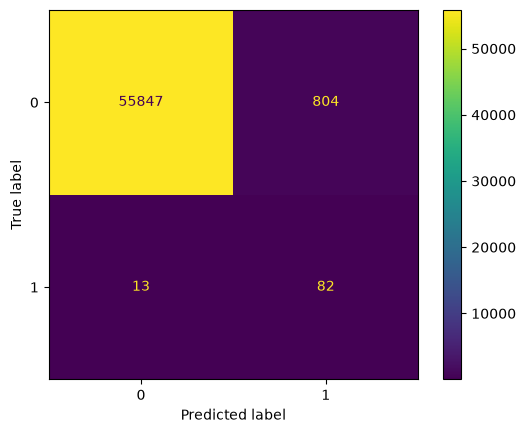

In [40]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()

plt.show()

## ROC-AUC

In [41]:
roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print(f"ROC-AUC : {roc_auc:.4f}")

ROC-AUC : 0.9729


## ROC Curve

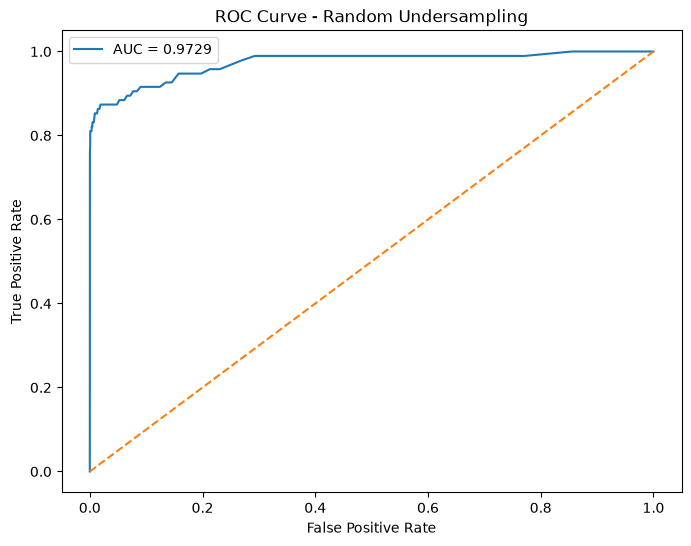

In [42]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Random Undersampling")

plt.legend()

plt.show()

## Feature Importance

In [43]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
14,V14,0.168467
10,V10,0.118463
12,V12,0.111466
17,V17,0.088663
11,V11,0.078169
3,V3,0.063339
4,V4,0.063162
7,V7,0.045794
16,V16,0.033732
2,V2,0.020893


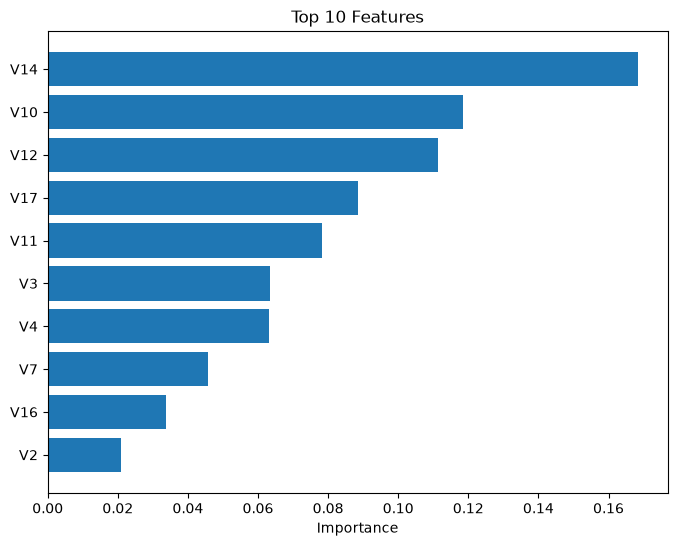

In [44]:
top10 = feature_importance.head(10)

plt.figure(figsize=(8,6))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Features")

plt.xlabel("Importance")

plt.show()

## Save Metrics

In [45]:
results = pd.DataFrame({
    "Model": ["Random Forest (Random Undersampling)"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1 Score": [f1],
    "ROC AUC": [roc_auc]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Random Forest (Random Undersampling),0.985603,0.092551,0.863158,0.167176,0.972907


In [46]:
import os

os.makedirs("../results", exist_ok=True)

results.to_csv(
    "../results/random_forest_random_undersampling_metrics.csv",
    index=False
)

# Final Observation

Random Undersampling reduced the majority class to match the minority class, creating a balanced training dataset.

Advantages:
- Faster training
- Better detection of fraud cases
- Simple implementation

Disadvantages:
- Discards many legitimate transactions
- May lose useful information
- Can reduce overall predictive performance compared to methods like SMOTE

This notebook will later be compared with the baseline Random Forest and the SMOTE approach to determine the most effective imbalance handling technique.

In [47]:
import joblib

joblib.dump(
    model,
    "../models/random_forest_random_undersampling.pkl"
)

print("Random Undersampling model saved successfully.")

Random Undersampling model saved successfully.
